In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
from scipy.fft import fft, fftfreq

1. Veri İncelemesi

In [2]:
df = pd.read_csv('havuz_sinyal_simulasyonu.csv')

In [3]:
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time_s           10000 non-null  float64
 1   pressure_signal  10000 non-null  float64
dtypes: float64(2)
memory usage: 156.4 KB
None
   time_s  pressure_signal
0   0.000         0.000104
1   0.001         0.038526
2   0.002         0.014421
3   0.003        -0.008561
4   0.004         0.014965


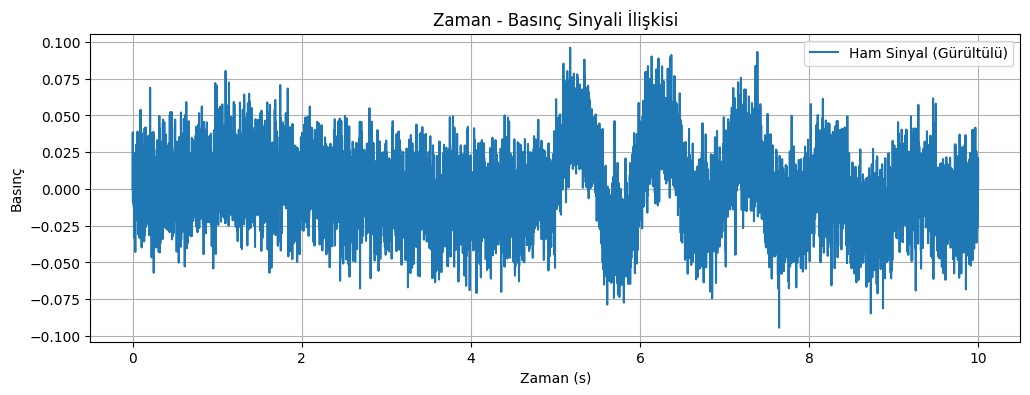

In [4]:
plt.figure(figsize=(12, 4))
plt.plot(df['time_s'], df['pressure_signal'], label='Ham Sinyal (Gürültülü)')
plt.title('Zaman - Basınç Sinyali İlişkisi')
plt.xlabel('Zaman (s)')
plt.ylabel('Basınç')
plt.legend()
plt.grid(True)
plt.show()

Sinyal 10 saniyelik, 10000 basınç verisine ve 1000Hz'lik bir örnekleme sahip. Yani sensör, saniyede 1000 ölçüm yaparark ayrık zamanlı bir veri seti oluşturur. 

2. Frekans Analizi

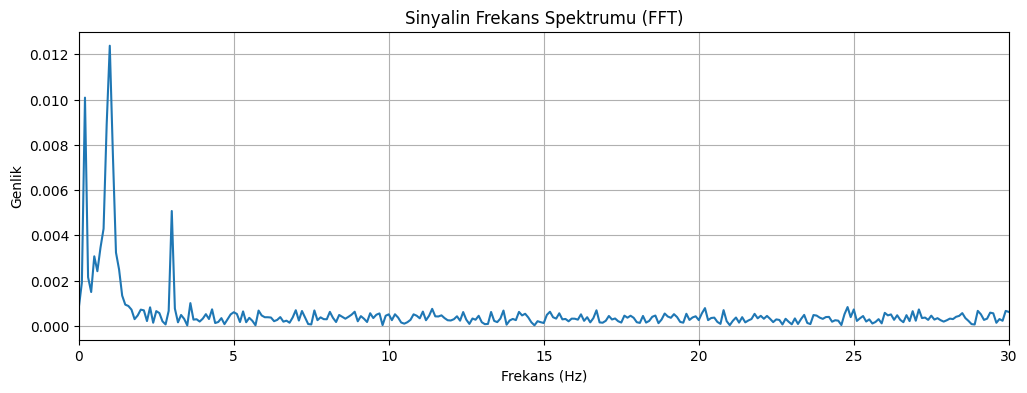

In [5]:
# 2. FFT Analizi
N = len(df)
fs = 1000  # Örnekleme frekansı (Hz)
yf = fft(df['pressure_signal'].values) 
xf = fftfreq(N, 1/fs)[:N//2] # Pozitif frekans bileşenlerini al

plt.figure(figsize=(12, 4)) 
plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))
plt.title('Sinyalin Frekans Spektrumu (FFT)')
plt.xlabel('Frekans (Hz)')
plt.ylabel('Genlik')
plt.xlim(0, 30) # İlk 30 Hz'e göre çizdir ana bileşen görünür olsun
plt.grid(True) 
plt.show()

FFT analizinde zamandan frekansa geçilerek sinyalin dominant bileşeni yaklaşık olarak 1Hz-2Hz'te bulunmuştur. FFT'nin simetri özelliğinden dolayı sadece pozitif bileşenler alınmıştır. (1000Hz/2=500Hz)

3. Gürültü Filtreleme

In [6]:
# 3. Gürültü Filtreleme 


#Parametreler
fs = 1000           # Örnekleme hızı 
cutoff = 10         # Kesim frekansı 
order = 4           # Filtre derecesi 

# 2. Butterworth Filtre Katsayılarını Hesapla
# low ile diyerek alçak geçiren (low-pass) olduğunu belirt
b, a = signal.butter(order, cutoff, btype='low', fs=fs)

# 3. Filtreyi Uygula
# 'filtfilt' (sıfır fazlı filtreleme) kullanarak sinyalin zaman ekseninde kaymasını önle
filtered_signal = signal.filtfilt(b, a, df['pressure_signal'])

# Sonucu yeni bir sütun olarak kaydedelim
df['filtered_pressure'] = filtered_signal

print("Filtreleme işlemi tamamlandı.")

Filtreleme işlemi tamamlandı.


4. Veri Görselleştirme

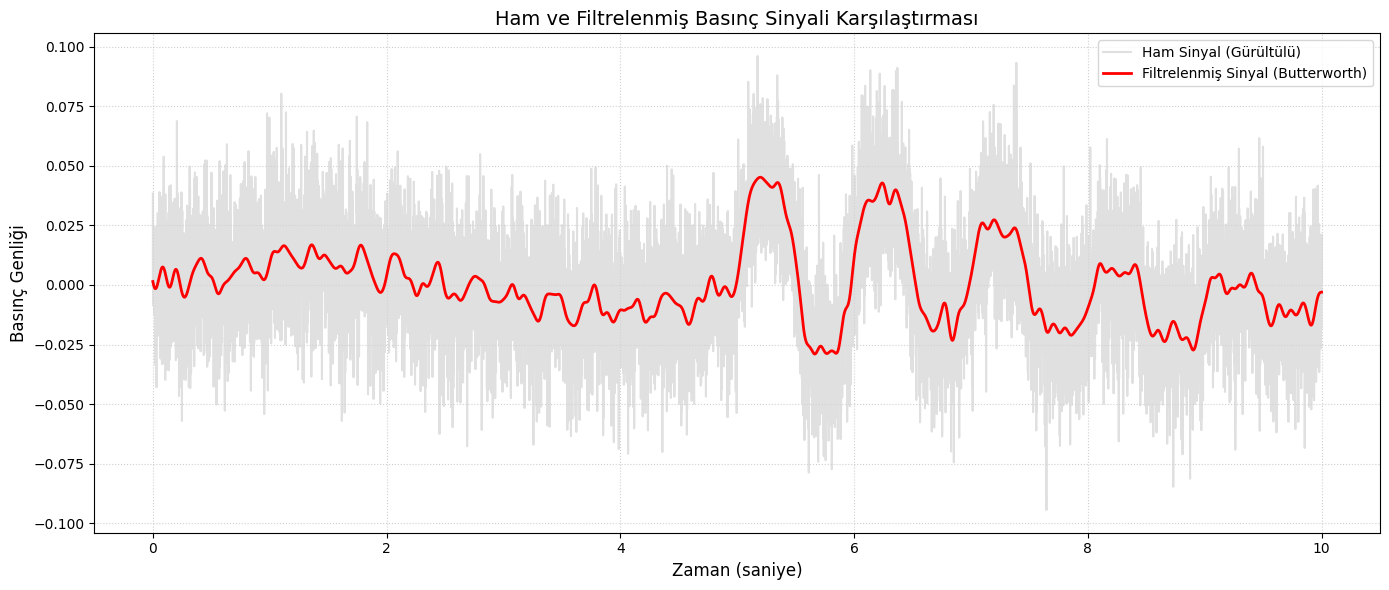

In [7]:
# 4. Veri Görselleştirme

plt.figure(figsize=(14, 6))

# 1. Ham Sinyal
plt.plot(df['time_s'], df['pressure_signal'], color='lightgray', alpha=0.7, label='Ham Sinyal (Gürültülü)')

# 2. Filtrelenmiş Sinyal
plt.plot(df['time_s'], filtered_signal, color='red', linewidth=2, label='Filtrelenmiş Sinyal (Butterworth)')

# Grafik Süslemeleri
plt.title('Ham ve Filtrelenmiş Basınç Sinyali Karşılaştırması', fontsize=14)
plt.xlabel('Zaman (saniye)', fontsize=12)
plt.ylabel('Basınç Genliği', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

# İstenilen aralıkta grafiği görebilmek için:
#plt.xlim(5, 7) 

plt.tight_layout()
plt.show()